![iSA logo](../iSA_logo.png)
### Materiały do zajęć Statystyka
#### Kurs Junior Data Scientist

**Wojciech Artichowicz**

In [1]:
import numpy as np
from scipy import stats as st
import matplotlib.pyplot as plt

In [2]:
with open("../X.txt","r") as file:
    X = np.array(list(map(lambda x: float(x),file.readlines())))

In [3]:
X.shape

(1000,)

In [4]:
X[0:10]

array([ 1.97519  , -0.962886 ,  2.97179  ,  0.423241 ,  0.0444927,
       -0.132216 ,  2.6524   , -2.14295  ,  0.166044 , -0.506884 ])

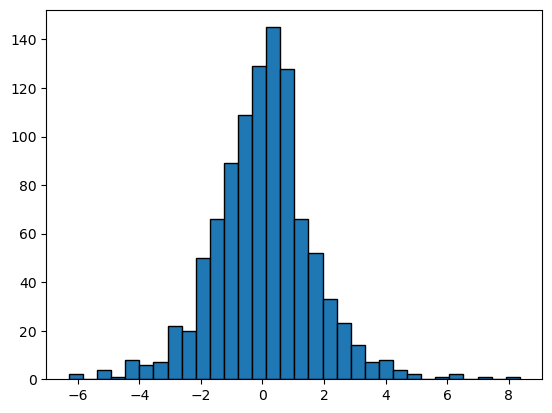

In [5]:
xmin = min(X)
xmax = max(X)
R = xmax-xmin
Q = np.quantile(X,[0.25, 0.75])
IQR = Q[-1] - Q[0]
h = 2.64*IQR/len(X)**(1/3) 
k = int(np.ceil(R/h))

hist = plt.hist(X,bins=k,edgecolor="black")

In [6]:
hist[0] #liczebności klas

array([  2.,   0.,   4.,   1.,   8.,   6.,   7.,  22.,  20.,  50.,  66.,
        89., 109., 129., 145., 128.,  66.,  52.,  33.,  23.,  14.,   7.,
         8.,   4.,   2.,   0.,   1.,   2.,   0.,   1.,   0.,   1.])

In [7]:
hist[1] # granice klas (mogą się nie pokrywać idealnie z tymi z zadania)

array([-6.29231   , -5.83432531, -5.37634062, -4.91835594, -4.46037125,
       -4.00238656, -3.54440187, -3.08641719, -2.6284325 , -2.17044781,
       -1.71246313, -1.25447844, -0.79649375, -0.33850906,  0.11947563,
        0.57746031,  1.035445  ,  1.49342969,  1.95141437,  2.40939906,
        2.86738375,  3.32536844,  3.78335313,  4.24133781,  4.6993225 ,
        5.15730719,  5.61529187,  6.07327656,  6.53126125,  6.98924594,
        7.44723063,  7.90521531,  8.3632    ])

In [8]:
class moj_rozklad(st.rv_continuous):
    "rozklad z zadania 3.2.3"
    def _pdf(self, x):
        return 2./(np.pi*(np.exp(x)+np.exp(-x)))
rozklad = moj_rozklad()

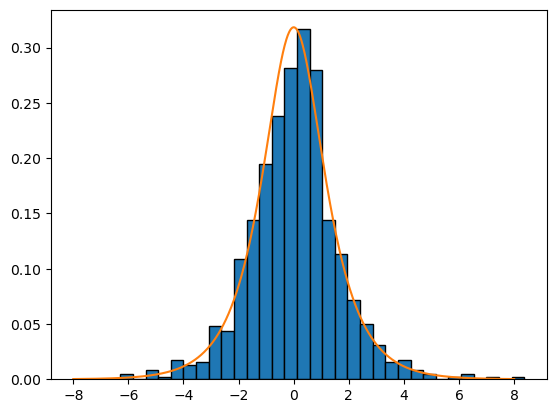

In [9]:
plt.hist(X,bins=k,edgecolor="black",density=True)
x = np.linspace(-8,8,1000)
plt.plot(x,rozklad.pdf(x))
pass

In [10]:
print([np.mean(X), rozklad.mean()])

[0.03286559671, 4.2680702173953795e-14]


C:\Users\wojci\AppData\Local\Temp\ipykernel_17492\2647853545.py:4: RuntimeWarning: overflow encountered in exp
  return 2./(np.pi*(np.exp(x)+np.exp(-x)))


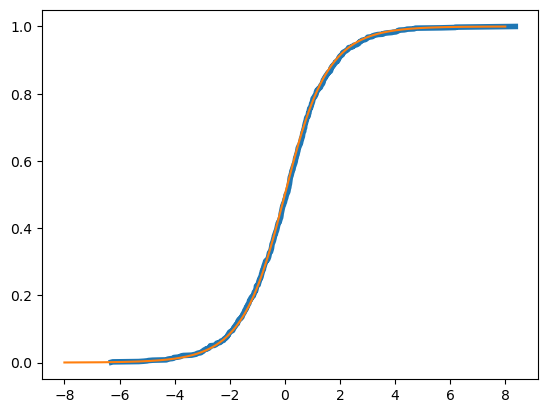

In [11]:
from statsmodels.distributions.empirical_distribution import ECDF # dystrybuanta empiryczna

ecdf = ECDF(X)
plt.plot(ecdf.x,ecdf.y,lw=4)
plt.plot(x,rozklad.cdf(x))

In [12]:
P = rozklad.cdf(2) - rozklad.cdf(0) # prawdopodobieństwo na podstawie rozkładu teoretycznego
Pe = ecdf(2) - ecdf(0) # prawdopodobieństwo na podstawie rozkładu empirycznego
print([P, Pe])

[0.4143631844053802, 0.42900000000000005]


C:\Users\wojci\AppData\Local\Temp\ipykernel_17492\2647853545.py:4: RuntimeWarning: overflow encountered in exp
  return 2./(np.pi*(np.exp(x)+np.exp(-x)))
